In [2]:
# Functions and imports
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from sklearn.svm import SVC
import scipy.special

def load_and_split_data():
    """Load and split the data into train and test sets."""
    # Load the data for all three classes
    class1_data = np.loadtxt('data/LS_data/Class1.txt')
    class2_data = np.loadtxt('data/LS_data/Class2.txt')
    class3_data = np.loadtxt('data/LS_data/Class3.txt')
    
    # Split function
    def train_test_split(data, test_size=0.3, random_state=42):
        np.random.seed(random_state)
        indices = np.random.permutation(len(data))
        split_idx = int(len(data) * (1 - test_size))
        return data[indices[:split_idx]], data[indices[split_idx:]]
    
    # Split each class
    train1, test1 = train_test_split(class1_data)
    train2, test2 = train_test_split(class2_data)
    train3, test3 = train_test_split(class3_data)
    
    return {
        'train': (train1, train2, train3),
        'test': (test1, test2, test3)
    }

class DataPreprocessor:
    def __init__(self):
        self.scaler = StandardScaler()
        
    def prepare_data(self, raw_data):
        """Prepare and scale the data."""
        # Combine all training data for scaling
        all_train_data = np.vstack(raw_data['train'])
        
        # Fit scaler on training data
        self.scaler.fit(all_train_data)
        
        # Transform all data
        scaled_data = {
            'train': tuple(self.scaler.transform(x) for x in raw_data['train']),
            'test': tuple(self.scaler.transform(x) for x in raw_data['test'])
        }
        
        return scaled_data

class GMMBayesClassifier:
    def __init__(self, n_components=1):
        self.n_components = n_components
        self.gmms = []
        self.priors = []
        
    def fit(self, class_data):
        """Fit GMM for each class."""
        total_samples = sum(len(X) for X in class_data)
        
        for X in class_data:
            # Calculate prior probability
            self.priors.append(len(X) / total_samples)
            
            # Fit GMM
            gmm = GaussianMixture(n_components=self.n_components, 
                                covariance_type='full',
                                random_state=42)
            gmm.fit(X)
            self.gmms.append(gmm)
    
    def predict(self, X):
        """Predict class labels using GMM-based Bayes classifier."""
        posteriors = []
        for gmm, prior in zip(self.gmms, self.priors):
            posteriors.append(np.exp(gmm.score_samples(X)) * prior)
        return np.argmax(np.array(posteriors).T, axis=1)

class KNNBayesClassifier:
    def __init__(self, k=1):
        self.k = k
        self.priors = []
        self.training_data = None
        
    def fit(self, class_data):
        """Store training data and calculate priors."""
        total_samples = sum(len(X) for X in class_data)
        self.training_data = class_data
        self.priors = [len(X) / total_samples for X in class_data]
    
    def _estimate_density(self, x, X):
        """Estimate density using KNN method."""
        distances = cdist([x], X)[0]
        k_dist = np.sort(distances)[min(self.k, len(distances)-1)]
        d = X.shape[1]
        volume = np.pi**(d/2) / scipy.special.gamma(d/2 + 1) * k_dist**d
        return self.k / (len(X) * volume)
    
    def predict(self, X):
        """Predict class labels."""
        predictions = []
        for x in X:
            densities = []
            for class_points, prior in zip(self.training_data, self.priors):
                density = self._estimate_density(x, class_points) * prior
                densities.append(density)
            predictions.append(np.argmax(densities))
        return np.array(predictions)

class FDAClassifier:
    def __init__(self, classifier_type='gaussian'):
        self.classifier_type = classifier_type
        self.w = None
        self.between_class_matrices = []
        self.within_class_scatter = None
        self.class_means = None
        self.gmms = None if classifier_type == 'gaussian' else []
        
    def fit(self, class_data):
        """Fit FDA for multiple classes."""
        n_classes = len(class_data)
        n_features = class_data[0].shape[1]
        
        # Calculate overall mean
        total_samples = np.vstack(class_data)
        overall_mean = np.mean(total_samples, axis=0)
        
        # Calculate class means
        self.class_means = [np.mean(X, axis=0) for X in class_data]
        
        # Calculate within-class scatter matrix
        self.within_class_scatter = np.zeros((n_features, n_features))
        for i, X in enumerate(class_data):
            diff = X - self.class_means[i]
            self.within_class_scatter += diff.T @ diff
            
        # Calculate between-class scatter matrix
        between_class_scatter = np.zeros((n_features, n_features))
        for i, mean in enumerate(self.class_means):
            diff = (mean - overall_mean).reshape(-1, 1)
            between_class_scatter += len(class_data[i]) * (diff @ diff.T)
            
        # Calculate projection matrix
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(
                np.linalg.inv(self.within_class_scatter) @ between_class_scatter
            )
            
            # Sort eigenvectors by eigenvalues in descending order
            idx = np.argsort(eigenvalues)[::-1]
            self.w = eigenvectors[:, idx[:n_classes-1]]
            
        except np.linalg.LinAlgError:
            # If matrix is singular, use pseudoinverse
            inv_within = np.linalg.pinv(self.within_class_scatter)
            eigenvalues, eigenvectors = np.linalg.eigh(inv_within @ between_class_scatter)
            idx = np.argsort(eigenvalues)[::-1]
            self.w = eigenvectors[:, idx[:n_classes-1]]
        
        # Transform training data and fit classifier
        transformed_data = [self.transform(X) for X in class_data]
        
        if self.classifier_type == 'gaussian':
            # Fit Gaussian parameters for each class
            self.gaussian_params = []
            for X_transformed in transformed_data:
                params = {
                    'mean': np.mean(X_transformed, axis=0),
                    'cov': np.cov(X_transformed.T)
                }
                self.gaussian_params.append(params)
        else:
            # Fit GMM for each class
            self.gmms = []
            for X_transformed in transformed_data:
                gmm = GaussianMixture(n_components=2, random_state=42)
                gmm.fit(X_transformed)
                self.gmms.append(gmm)
    
    def transform(self, X):
        """Project data onto FDA space."""
        return X @ self.w
    
    def predict(self, X):
        """Predict class labels."""
        X_transformed = self.transform(X)
        
        if self.classifier_type == 'gaussian':
            # Calculate likelihood for each class using Gaussian assumption
            likelihoods = []
            for params in self.gaussian_params:
                likelihood = multivariate_normal.pdf(
                    X_transformed,
                    mean=params['mean'],
                    cov=params['cov']
                )
                likelihoods.append(likelihood)
        else:
            # Calculate likelihood using GMMs
            likelihoods = []
            for gmm in self.gmms:
                likelihood = np.exp(gmm.score_samples(X_transformed))
                likelihoods.append(likelihood)
        
        return np.argmax(likelihoods, axis=0)

class MulticlassPerceptron:
    def __init__(self, n_classes, n_features, learning_rate=0.01, max_iterations=1000):
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.weights = np.zeros((n_classes, n_features))
        self.biases = np.zeros(n_classes)
        
    def fit(self, X, y):
        """Train multiclass perceptron."""
        for _ in range(self.max_iterations):
            errors = 0
            for xi, yi in zip(X, y):
                # Calculate scores for each class
                scores = np.dot(self.weights, xi) + self.biases
                predicted_class = np.argmax(scores)
                
                # Update weights if prediction is wrong
                if predicted_class != yi:
                    errors += 1
                    self.weights[yi] += self.learning_rate * xi
                    self.weights[predicted_class] -= self.learning_rate * xi
                    self.biases[yi] += self.learning_rate
                    self.biases[predicted_class] -= self.learning_rate
            
            if errors == 0:
                break
    
    def predict(self, X):
        """Predict class labels."""
        scores = np.dot(X, self.weights.T) + self.biases
        return np.argmax(scores, axis=1)

class MulticlassLogisticRegression:
    def __init__(self, n_classes, n_features, learning_rate=0.01, max_iterations=1000):
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.weights = np.zeros((n_classes, n_features))
        self.biases = np.zeros(n_classes)
        
    def softmax(self, z):
        """Compute softmax values."""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
        
    def fit(self, X, y):
        """Train multiclass logistic regression."""
        n_samples = X.shape[0]
        
        for _ in range(self.max_iterations):
            # Forward pass
            scores = np.dot(X, self.weights.T) + self.biases
            probabilities = self.softmax(scores)
            
            # Convert labels to one-hot encoding
            y_one_hot = np.zeros((n_samples, self.n_classes))
            y_one_hot[np.arange(n_samples), y] = 1
            
            # Compute gradients
            dw = (1/n_samples) * np.dot(X.T, (probabilities - y_one_hot)).T
            db = (1/n_samples) * np.sum(probabilities - y_one_hot, axis=0)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.biases -= self.learning_rate * db
    
    def predict(self, X):
        """Predict class labels."""
        scores = np.dot(X, self.weights.T) + self.biases
        return np.argmax(self.softmax(scores), axis=1)

def plot_decision_regions_2d(X, y, classifier, title, plot_step=0.02):
    """Plot decision regions for 2D data."""
    plt.figure(figsize=(10, 8))
    
    # Define the minimum and maximum values
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                        np.arange(y_min, y_max, plot_step))
    
    # Predict for each point in the mesh
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision regions
    plt.contourf(xx, yy, Z, alpha=0.4)
    
    # Plot the training points
    for i in range(3):  # For 3 classes
        plt.scatter(X[y == i, 0], X[y == i, 1], alpha=0.8, label=f'Class {i+1}')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_fda_projections(X_list, fda, title):
    """Plot FDA projections for multiple classes."""
    plt.figure(figsize=(15, 5))
    
    # Original space with FDA directions
    plt.subplot(1, 2, 1)
    colors = ['red', 'blue', 'green']
    for i, X in enumerate(X_list):
        plt.scatter(X[:, 0], X[:, 1], c=colors[i], label=f'Class {i+1}')
    
    # Plot FDA directions
    scale = 2.0
    origin = np.zeros(2)
    for i in range(fda.w.shape[1]):
        plt.arrow(origin[0], origin[1], 
                 scale * fda.w[0, i], scale * fda.w[1, i],
                 color='black', head_width=0.1)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Original Space with FDA Directions')
    plt.legend()
    
    # Projected space
    plt.subplot(1, 2, 2)
    for i, X in enumerate(X_list):
        projected_X = fda.transform(X)
        if projected_X.shape[1] == 1:
            plt.hist(projected_X, bins=20, alpha=0.5, color=colors[i], 
                    label=f'Class {i+1}')
        else:
            plt.scatter(projected_X[:, 0], projected_X[:, 1], 
                       c=colors[i], label=f'Class {i+1}')
    
    plt.xlabel('First FDA Component')
    plt.ylabel('Second FDA Component' if fda.w.shape[1] > 1 else 'Count')
    plt.title('FDA Projected Space')
    plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def evaluate_classifier(y_true, y_pred):
    """Evaluate classifier performance with detailed metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, 
                                                             average=None)
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Calculate mean metrics
    mean_precision = np.mean(precision)
    mean_recall = np.mean(recall)
    mean_f1 = np.mean(f1)
    
    results = {
        'accuracy': accuracy,
        'precision': {f'Class {i+1}': p for i, p in enumerate(precision)},
        'recall': {f'Class {i+1}': r for i, r in enumerate(recall)},
        'f1': {f'Class {i+1}': f for i, f in enumerate(f1)},
        'mean_precision': mean_precision,
        'mean_recall': mean_recall,
        'mean_f1': mean_f1,
        'confusion_matrix': conf_matrix
    }
    
    return results

def print_evaluation_results(results):
    """Print evaluation results in a formatted way."""
    print("\nClassification Results:")
    print(f"Accuracy: {results['accuracy']:.4f}")
    
    print("\nPer-class metrics:")
    for class_name in results['precision'].keys():
        print(f"\n{class_name}:")
        print(f"Precision: {results['precision'][class_name]:.4f}")
        print(f"Recall: {results['recall'][class_name]:.4f}")
        print(f"F1-score: {results['f1'][class_name]:.4f}")
    
    print("\nMean metrics:")
    print(f"Mean Precision: {results['mean_precision']:.4f}")
    print(f"Mean Recall: {results['mean_recall']:.4f}")
    print(f"Mean F1-score: {results['mean_f1']:.4f}")
    
    print("\nConfusion Matrix:")
    print(results['confusion_matrix'])


In [3]:
# 1. Load and prepare data
print("Loading and preparing data...")
raw_data = load_and_split_data()
preprocessor = DataPreprocessor()
data = preprocessor.prepare_data(raw_data)

# Prepare combined training and test data
X_train = np.vstack(data['train'])
y_train = np.hstack([np.full(len(data['train'][i]), i) for i in range(3)])
X_test = np.vstack(data['test'])
y_test = np.hstack([np.full(len(data['test'][i]), i) for i in range(3)])

# Dictionary to store all results
all_results = {}

Loading and preparing data...



Training GMM-based Bayes Classifiers...

GMM with 1 components:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


<Figure size 1000x800 with 0 Axes>

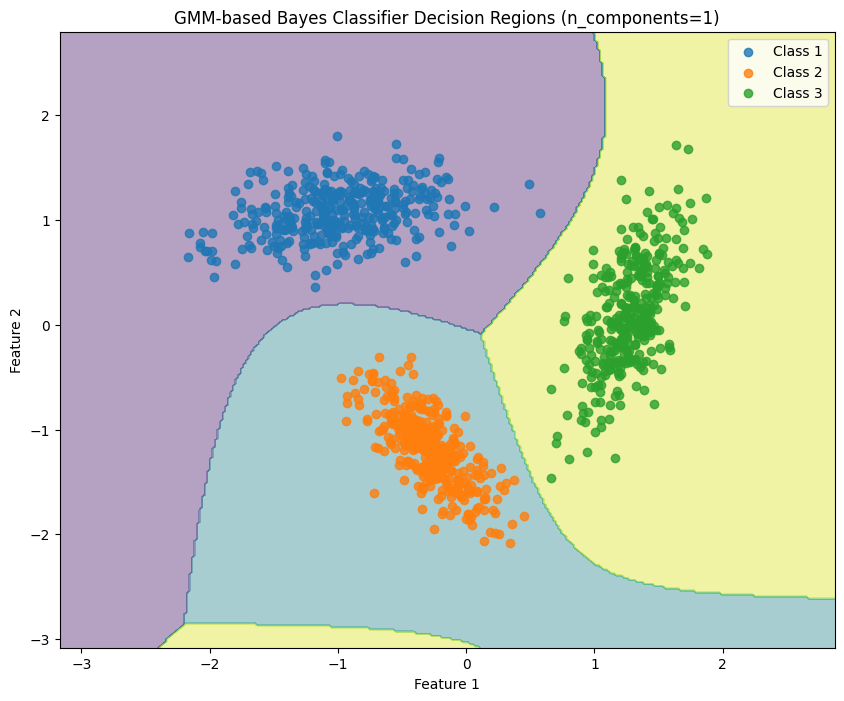

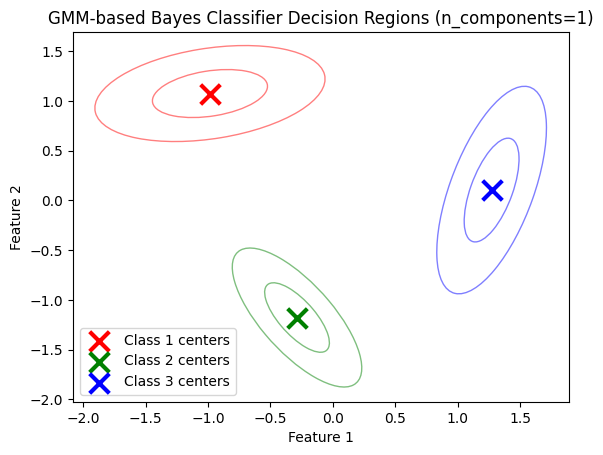


GMM with 2 components:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


<Figure size 1000x800 with 0 Axes>

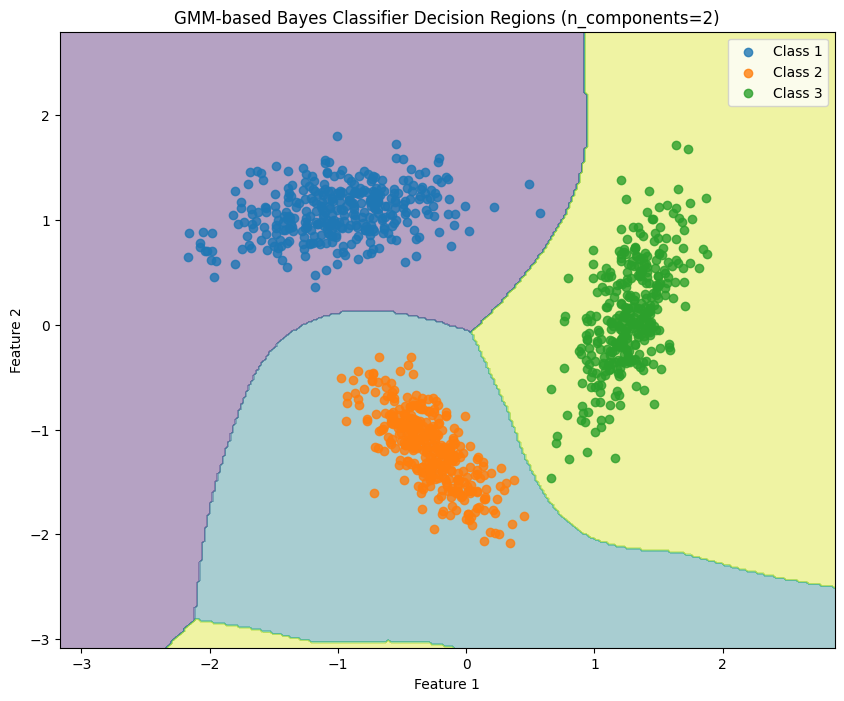

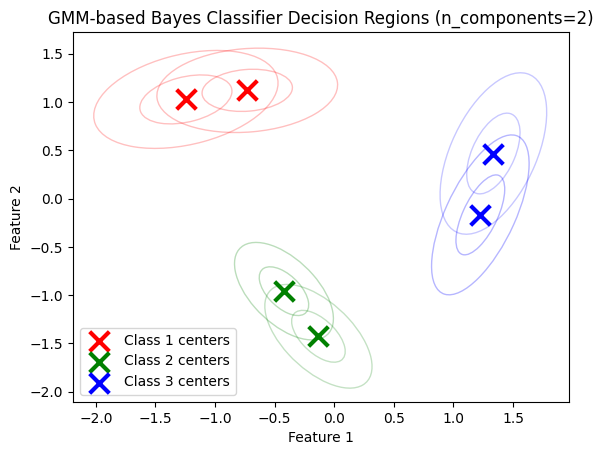


GMM with 4 components:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


<Figure size 1000x800 with 0 Axes>

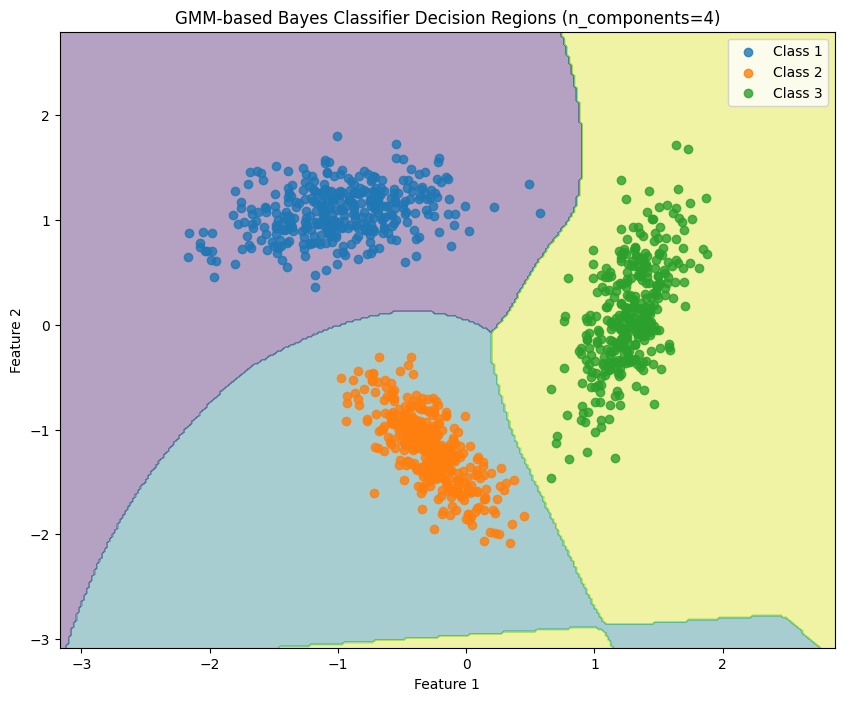

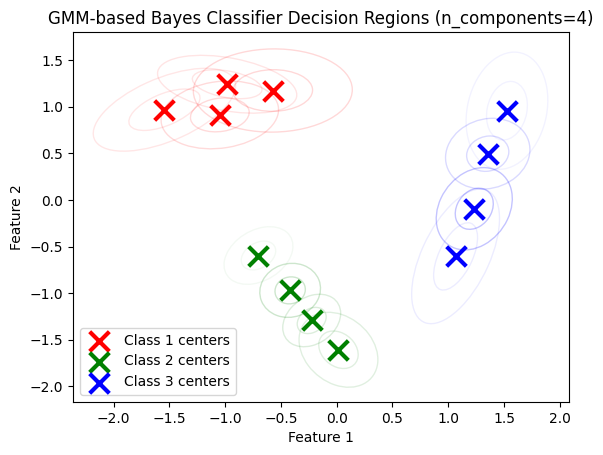


GMM with 8 components:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


<Figure size 1000x800 with 0 Axes>

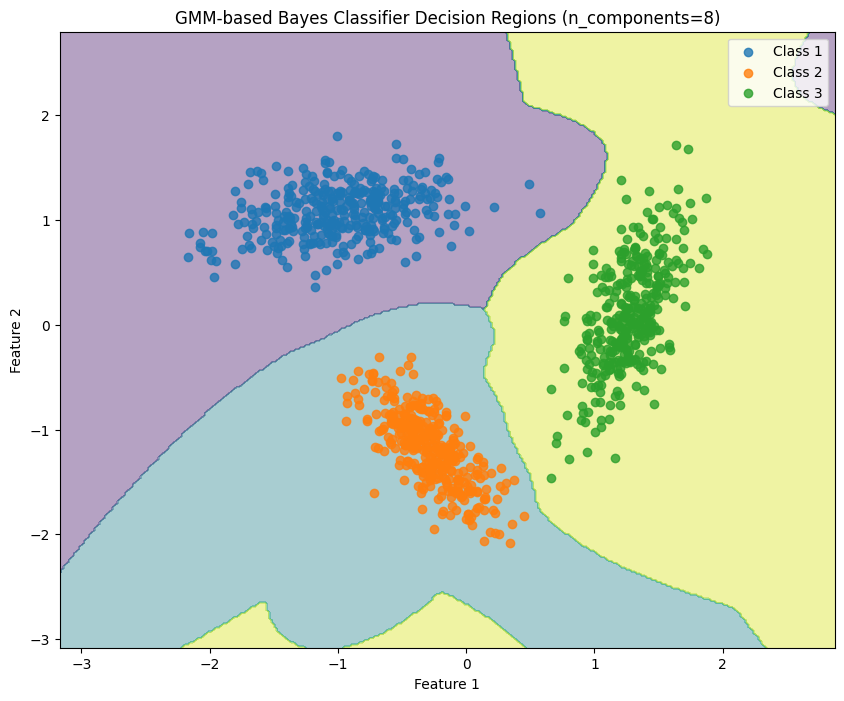

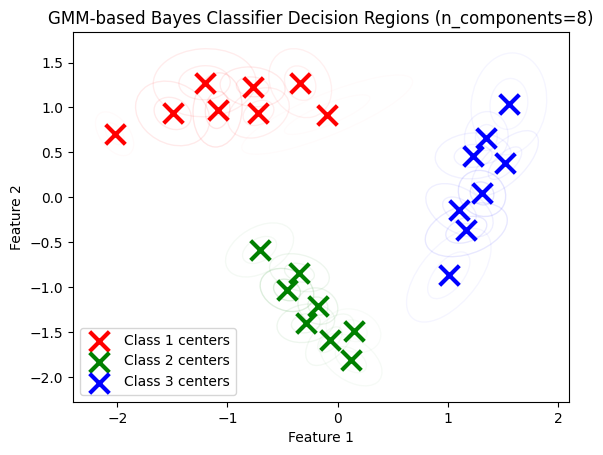

In [4]:
# Training GMM-based Bayes Classifiers
import matplotlib.patches as patches
print("\nTraining GMM-based Bayes Classifiers...")
for n_components in [1, 2, 4, 8, 16]:
    gmm_clf = GMMBayesClassifier(n_components=n_components)
    gmm_clf.fit(data['train'])
    y_pred = gmm_clf.predict(X_test)
    results = evaluate_classifier(y_test, y_pred)
    all_results[f'GMM_{n_components}'] = results
    print(f"\nGMM with {n_components} components:")
    print_evaluation_results(results)
    
    # Plot decision regions
    plt.figure(figsize=(10, 8))
    title = f'GMM-based Bayes Classifier Decision Regions (n_components={n_components})'
    plot_decision_regions_2d(X_train, y_train, gmm_clf, title)
    
    # Also plot the GMM components
    colors = ['r', 'g', 'b']
    for i, gmm in enumerate(gmm_clf.gmms):
        means = gmm.means_
        covs = gmm.covariances_
        weights = gmm.weights_
        
        # Plot the centers of each component
        plt.scatter(means[:, 0], means[:, 1], 
                   c=colors[i], marker='x', s=200, linewidth=3,
                   label=f'Class {i+1} centers')
                   
        # Plot the covariance ellipses
        for j, (mean, covar, weight) in enumerate(zip(means, covs, weights)):
            if covar.shape == (2, 2):
                eigenvals, eigenvects = np.linalg.eigh(covar)
                angle = np.degrees(np.arctan2(eigenvects[1, 0], eigenvects[0, 0]))
                
                for nstd in [1, 2]:
                    ax = plt.gca()
                    ellip = patches.Ellipse(mean, 2*nstd*np.sqrt(eigenvals[0]),
                                          2*nstd*np.sqrt(eigenvals[1]),
                                          angle=angle,
                                          fill=False,
                                          color=colors[i],
                                          alpha=weight*0.5)
                    ax.add_patch(ellip)
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()


Training KNN-based Bayes Classifiers...

KNN with k=1:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


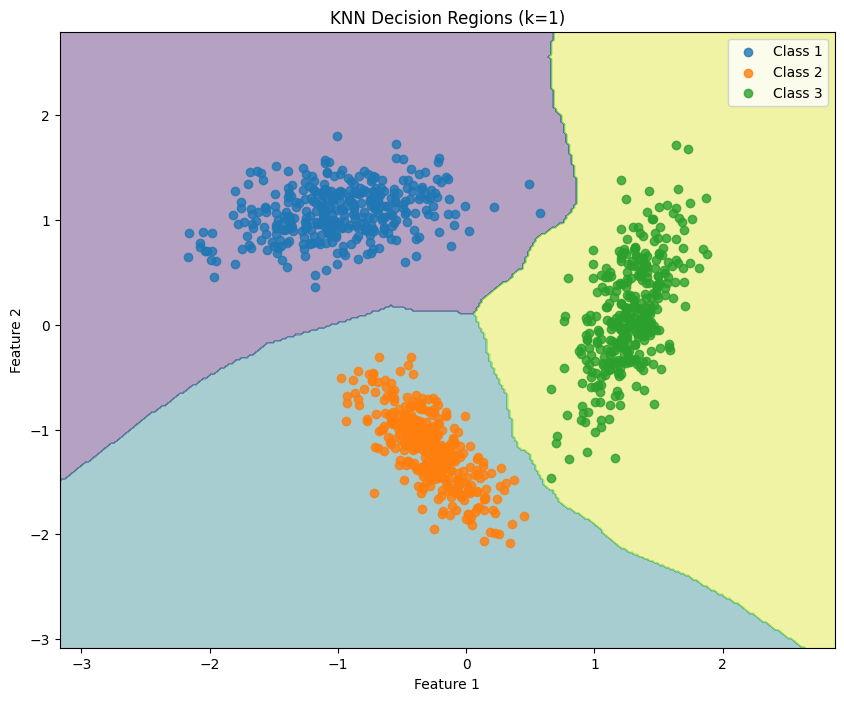


KNN with k=3:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


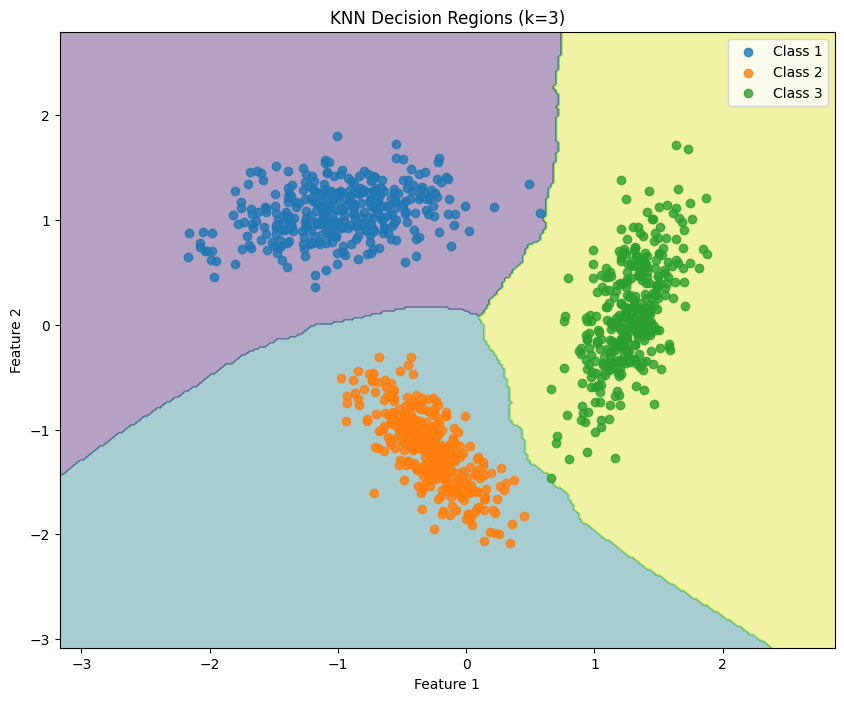


KNN with k=5:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


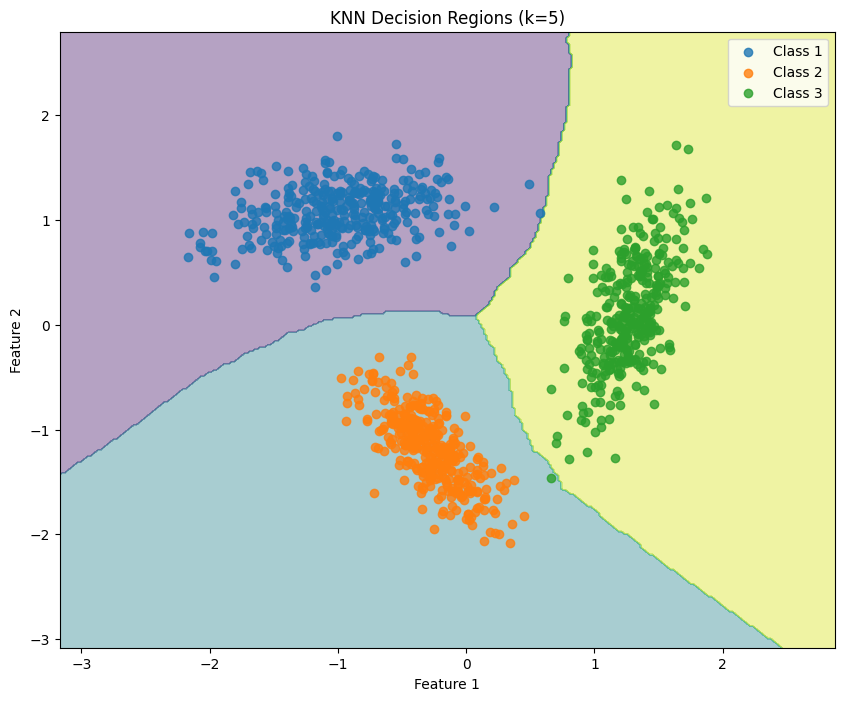


KNN with k=7:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


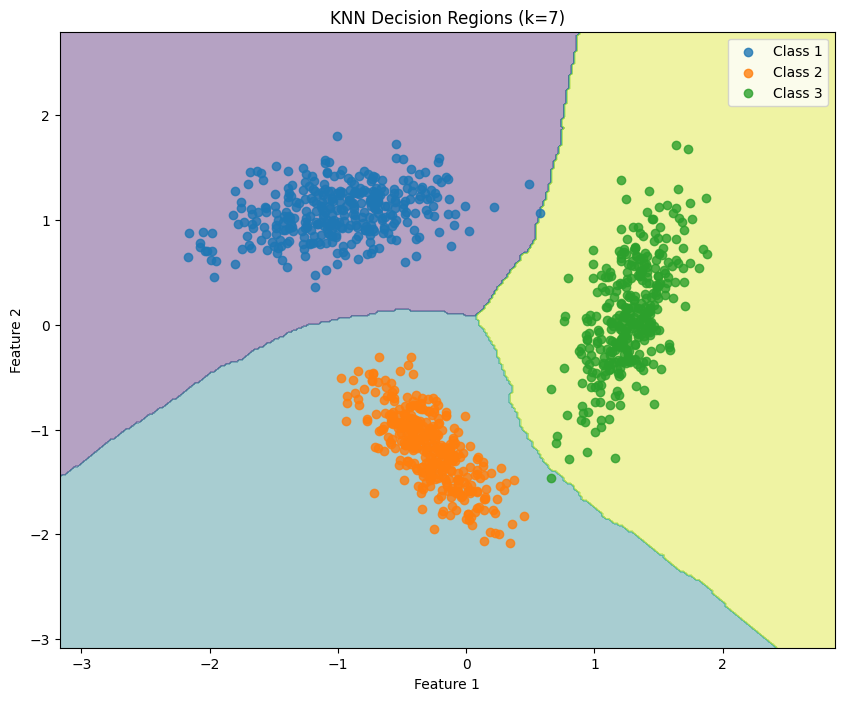

In [5]:
# 3. KNN-based Bayes Classifier
print("\nTraining KNN-based Bayes Classifiers...")
for k in [1, 3, 5, 7]:
    knn_clf = KNNBayesClassifier(k=k)
    knn_clf.fit(data['train'])
    y_pred = knn_clf.predict(X_test)
    results = evaluate_classifier(y_test, y_pred)
    all_results[f'KNN_{k}'] = results
    print(f"\nKNN with k={k}:")
    print_evaluation_results(results)
    
    # Plot decision regions
    plot_decision_regions_2d(X_train, y_train, knn_clf, f'KNN Decision Regions (k={k})')



Training FDA Classifiers...

FDA with Gaussian assumption:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]

FDA with GMM:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


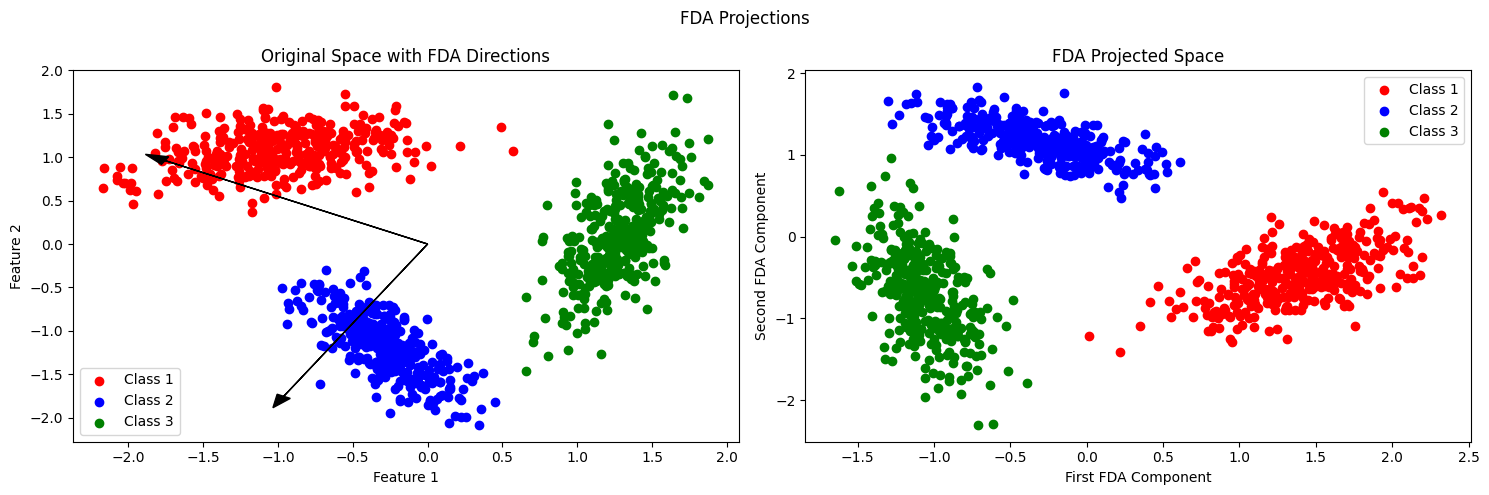

In [6]:
# 4. FDA Classifier
print("\nTraining FDA Classifiers...")
# With Gaussian assumption
fda_gaussian = FDAClassifier(classifier_type='gaussian')
fda_gaussian.fit(data['train'])
y_pred = fda_gaussian.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['FDA_Gaussian'] = results
print("\nFDA with Gaussian assumption:")
print_evaluation_results(results)

# With GMM
fda_gmm = FDAClassifier(classifier_type='gmm')
fda_gmm.fit(data['train'])
y_pred = fda_gmm.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['FDA_GMM'] = results
print("\nFDA with GMM:")
print_evaluation_results(results)

# Plot FDA projections
plot_fda_projections(data['train'], fda_gaussian, 'FDA Projections')


Training Multiclass Perceptron...

Multiclass Perceptron:

Classification Results:
Accuracy: 0.9978

Per-class metrics:

Class 1:
Precision: 0.9934
Recall: 1.0000
F1-score: 0.9967

Class 2:
Precision: 1.0000
Recall: 0.9933
F1-score: 0.9967

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 0.9978
Mean Recall: 0.9978
Mean F1-score: 0.9978

Confusion Matrix:
[[150   0   0]
 [  1 149   0]
 [  0   0 150]]


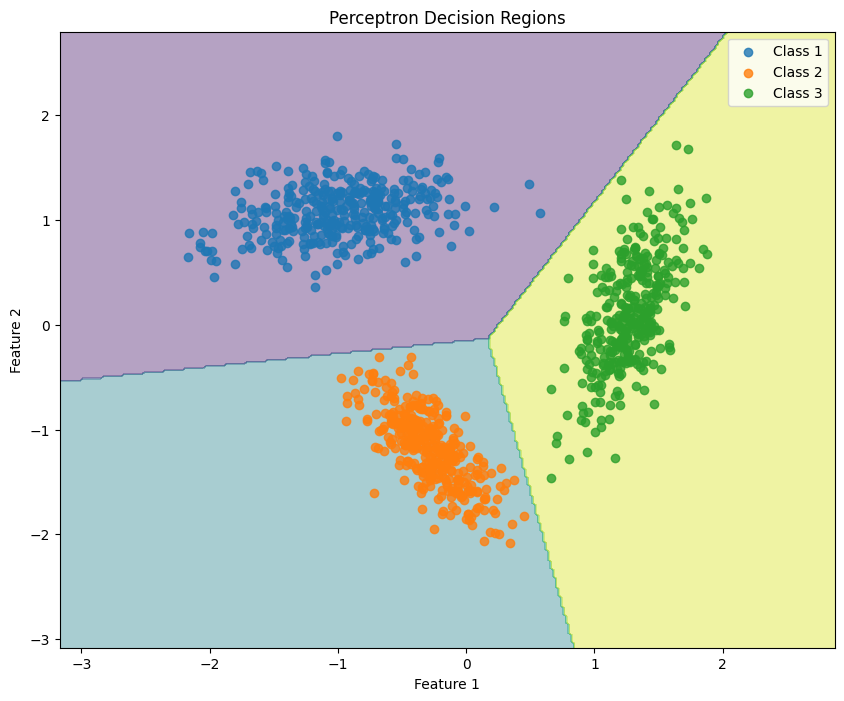

In [7]:
# 5. Multiclass Perceptron
print("\nTraining Multiclass Perceptron...")
perceptron = MulticlassPerceptron(n_classes=3, n_features=X_train.shape[1])
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['Perceptron'] = results
print("\nMulticlass Perceptron:")
print_evaluation_results(results)

# Plot decision regions
plot_decision_regions_2d(X_train, y_train, perceptron, 'Perceptron Decision Regions')



Training Multiclass Logistic Regression...

Multiclass Logistic Regression:

Classification Results:
Accuracy: 0.9978

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 0.9934
Recall: 1.0000
F1-score: 0.9967

Class 3:
Precision: 1.0000
Recall: 0.9933
F1-score: 0.9967

Mean metrics:
Mean Precision: 0.9978
Mean Recall: 0.9978
Mean F1-score: 0.9978

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   1 149]]


Training Multiclass Logistic Regression...

Multiclass Logistic Regression:

Classification Results:
Accuracy: 0.9978

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 0.9934
Recall: 1.0000
F1-score: 0.9967

Class 3:
Precision: 1.0000
Recall: 0.9933
F1-score: 0.9967

Mean metrics:
Mean Precision: 0.9978
Mean Recall: 0.9978
Mean F1-score: 0.9978

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   1 149]]


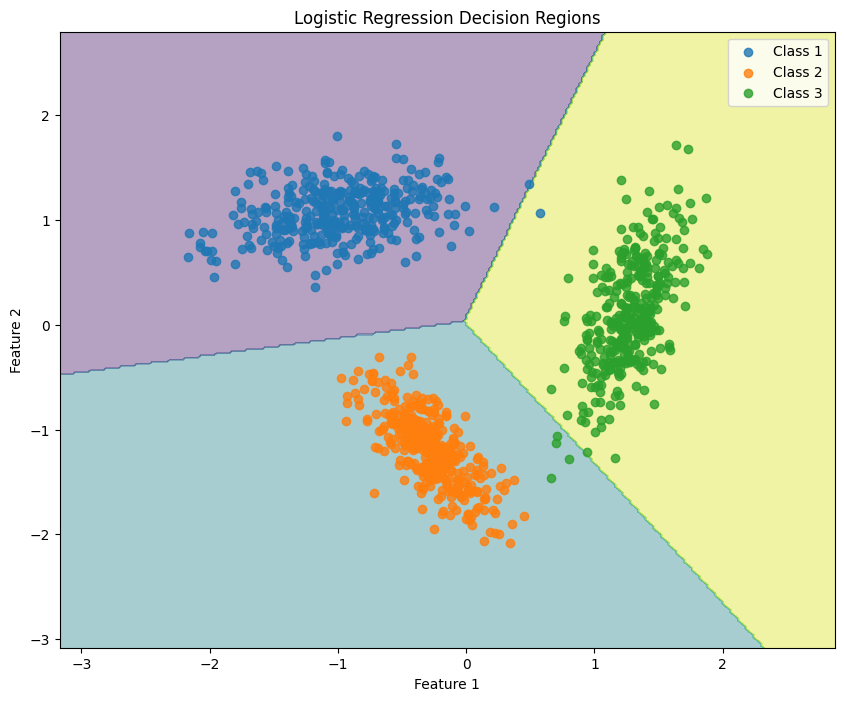

In [9]:
# 6. Multiclass Logistic Regression
print("\nTraining Multiclass Logistic Regression...")
logistic = MulticlassLogisticRegression(n_classes=3, n_features=X_train.shape[1])
logistic.fit(X_train, y_train)
y_pred = logistic.predict(X_test)
results = evaluate_classifier(y_test, y_pred)
all_results['Logistic_Regression'] = results
print("\nMulticlass Logistic Regression:")
print_evaluation_results(results)

# Plot decision regions
plot_decision_regions_2d(X_train, y_train, logistic, 'Logistic Regression Decision Regions')



Training SVM Classifiers...

SVM_linear:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


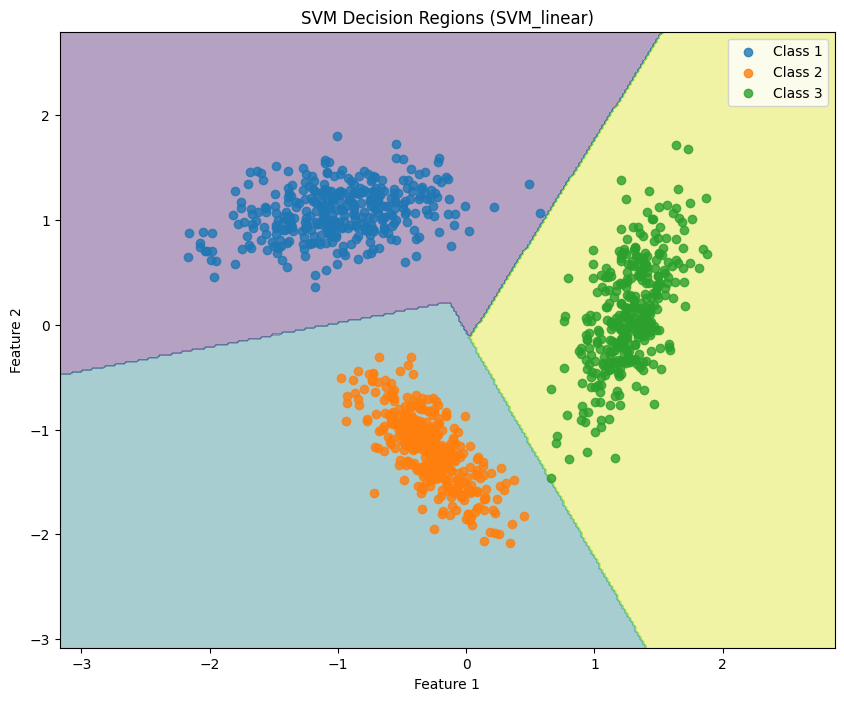


SVM_poly_degree2:

Classification Results:
Accuracy: 0.9489

Per-class metrics:

Class 1:
Precision: 0.9329
Recall: 0.9267
F1-score: 0.9298

Class 2:
Precision: 0.9801
Recall: 0.9867
F1-score: 0.9834

Class 3:
Precision: 0.9333
Recall: 0.9333
F1-score: 0.9333

Mean metrics:
Mean Precision: 0.9488
Mean Recall: 0.9489
Mean F1-score: 0.9488

Confusion Matrix:
[[139   3   8]
 [  0 148   2]
 [ 10   0 140]]


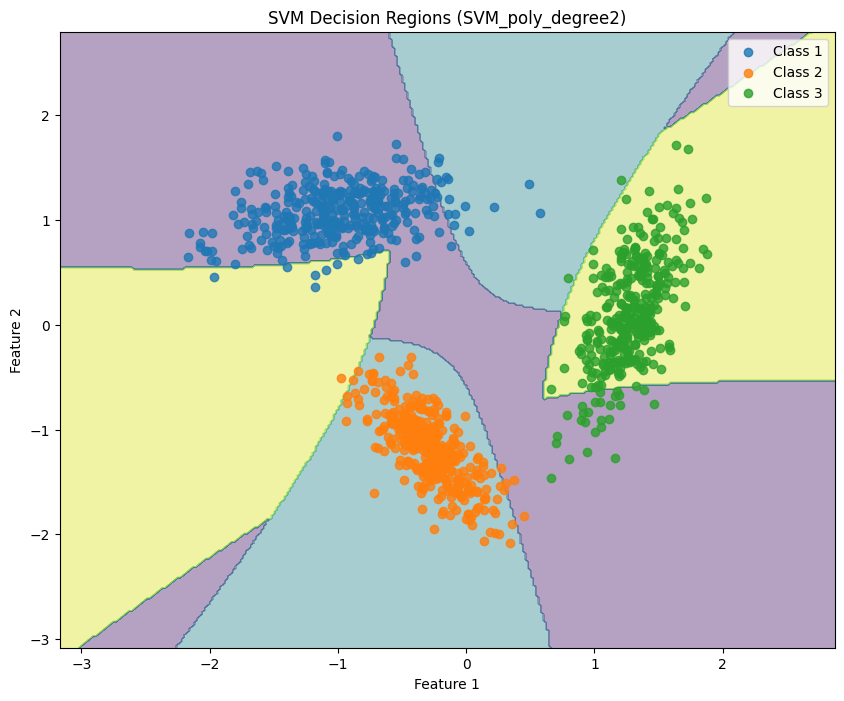


SVM_poly_degree3:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


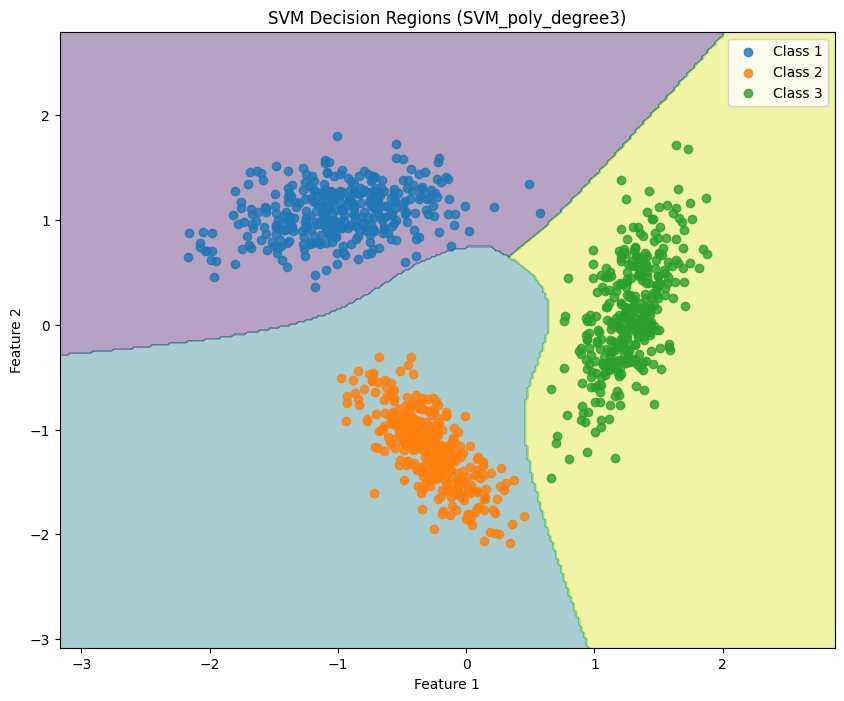


SVM_rbf:

Classification Results:
Accuracy: 1.0000

Per-class metrics:

Class 1:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 2:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class 3:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Mean metrics:
Mean Precision: 1.0000
Mean Recall: 1.0000
Mean F1-score: 1.0000

Confusion Matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0 150]]


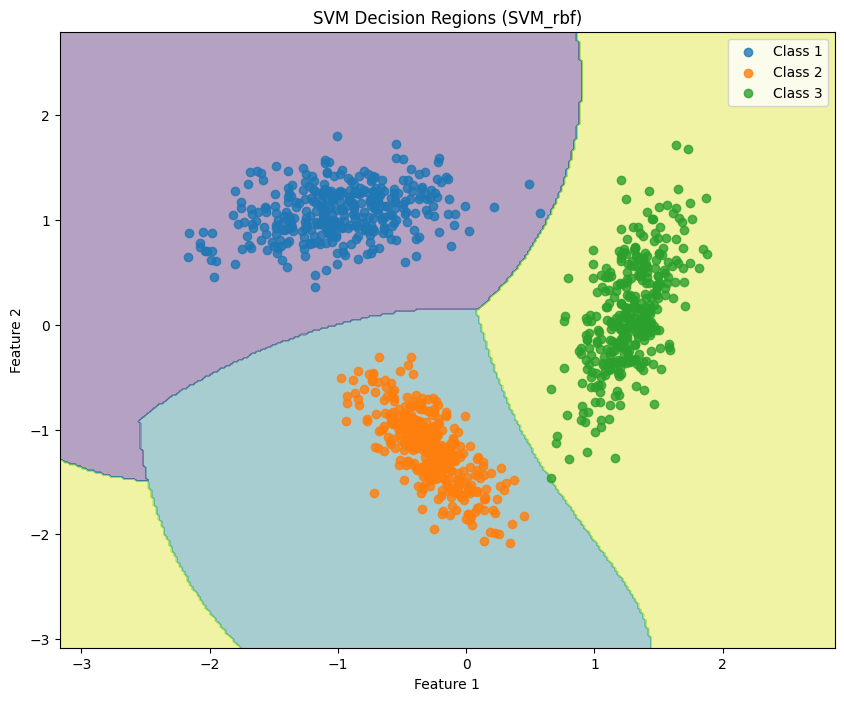

In [8]:
# 7. SVM
print("\nTraining SVM Classifiers...")
kernel_configs = [
    {'kernel': 'linear', 'C': 1.0},
    {'kernel': 'poly', 'degree': 2, 'C': 1.0},
    {'kernel': 'poly', 'degree': 3, 'C': 1.0},
    {'kernel': 'rbf', 'gamma': 'scale', 'C': 1.0}
]

for config in kernel_configs:
    name = f"SVM_{config['kernel']}"
    if config['kernel'] == 'poly':
        name += f"_degree{config['degree']}"
    
    svm = SVC(**config)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    results = evaluate_classifier(y_test, y_pred)
    all_results[name] = results
    print(f"\n{name}:")
    print_evaluation_results(results)
    
    # Create a wrapper class for the sklearn SVM to match our interface
    class SVMWrapper:
        def __init__(self, svm_model):
            self.model = svm_model
        def predict(self, X):
            return self.model.predict(X)
    
    # Plot decision regions
    plot_decision_regions_2d(X_train, y_train, SVMWrapper(svm), 
                            f'SVM Decision Regions ({name})')

# Save results
np.save('classifier_results.npy', all_results)

In [11]:
# Print final comparison
print("\nFinal Accuracy Comparison:")
accuracies = {name: results['accuracy'] for name, results in all_results.items()}
for name, acc in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")













Final Accuracy Comparison:
GMM_1: 1.0000
GMM_2: 1.0000
GMM_4: 1.0000
GMM_8: 1.0000
KNN_1: 1.0000
KNN_3: 1.0000
KNN_5: 1.0000
KNN_7: 1.0000
FDA_Gaussian: 1.0000
FDA_GMM: 1.0000
SVM_linear: 1.0000
SVM_poly_degree3: 1.0000
SVM_rbf: 1.0000
Perceptron: 0.9978
Logistic_Regression: 0.9978
SVM_poly_degree2: 0.9489


Final Accuracy Comparison:
GMM_1: 1.0000
GMM_2: 1.0000
GMM_4: 1.0000
GMM_8: 1.0000
KNN_1: 1.0000
KNN_3: 1.0000
KNN_5: 1.0000
KNN_7: 1.0000
FDA_Gaussian: 1.0000
FDA_GMM: 1.0000
SVM_linear: 1.0000
SVM_poly_degree3: 1.0000
SVM_rbf: 1.0000
Perceptron: 0.9978
Logistic_Regression: 0.9978
SVM_poly_degree2: 0.9489
